# Rates Modeling

# Heath–Jarrow–Morton (HJM) Framework

* Under the risk-neutral probability, once forward rate vol is determined, so is its drift 
* $f(t, T)$: Instantaneous forward rate
    * Forward rate for the reference period $[T, T+\epsilon]$ observed at $t$
* $\sigma(t, T)$: Forward rate vol
$$
df(t, T) = O(dt) + \sigma(t, T)\,d\widetilde W(t), \qquad t<T
$$
* Think of a fixed $T$, say 10y

# Heath–Jarrow–Morton (HJM) Framework (Cont.)

$$
df_{\text{10y}}(t) = O(dt) + \sigma_{\text{10y}}(t)\,d\widetilde W(t), \qquad t<\text{10y}
$$

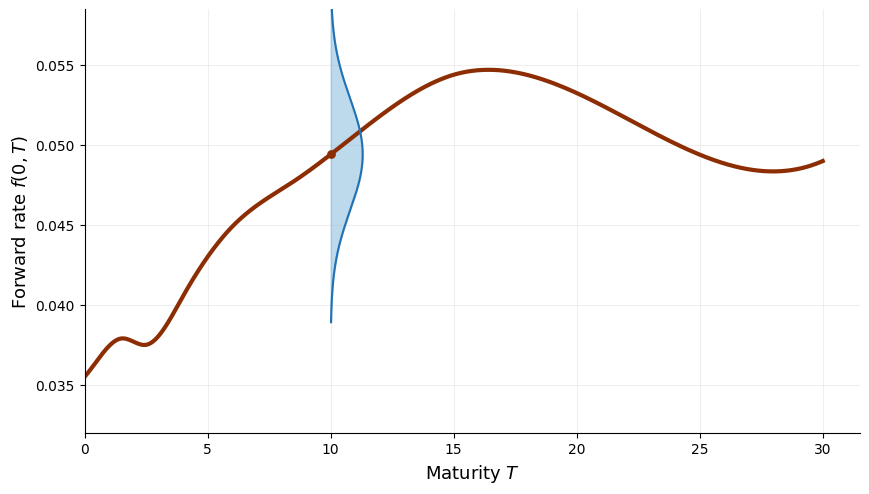

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

fwd_knots = np.array([0.0, 0.5, 1.5, 2.5, 4.0, 6.0, 8.5, 15.0, 25.0, 30.0])
fwd_vals  = np.array([0.0355, 0.0365, 0.0379, 0.0375, 0.04055, 0.0449, 0.04773, 0.0544, 0.0494, 0.0490])
cs = CubicSpline(fwd_knots, fwd_vals, bc_type='not-a-knot')
maturity = np.linspace(0, 30, 1201)
forward_curve = cs(maturity)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(maturity, forward_curve, color='#8c2d04', linewidth=3)

pillars = np.array([10.0])
pillar_forwards = cs(pillars)
vols = np.array([0.0035])
width_scale = 1.3

for pillar, center, vol in zip(pillars, pillar_forwards, vols):
    move = np.linspace(-3 * vol, 3 * vol, 250)
    density = np.exp(-0.5 * (move / vol) ** 2)
    density /= density.max()
    x_right = pillar + width_scale * density
    ax.fill_betweenx(center + move, pillar, x_right, color='#6baed6', alpha=0.45)
    ax.plot(x_right, center + move, color='#2171b5', linewidth=1.5)
    ax.scatter([pillar], [center], color='#8c2d04', s=28, zorder=3)

ax.set_xlim(0, 31.5)
ax.set_ylim(0.032, 0.0585)
ax.set_xlabel('Maturity $T$', fontsize=13)
ax.set_ylabel('Forward rate $f(0,T)$', fontsize=13)
ax.grid(alpha=0.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()


# Heath–Jarrow–Morton (HJM) Framework (Cont..)

$$
df(t, T) = O(dt) + \sigma(t, T)\,d\widetilde W(t), \qquad t<T
$$

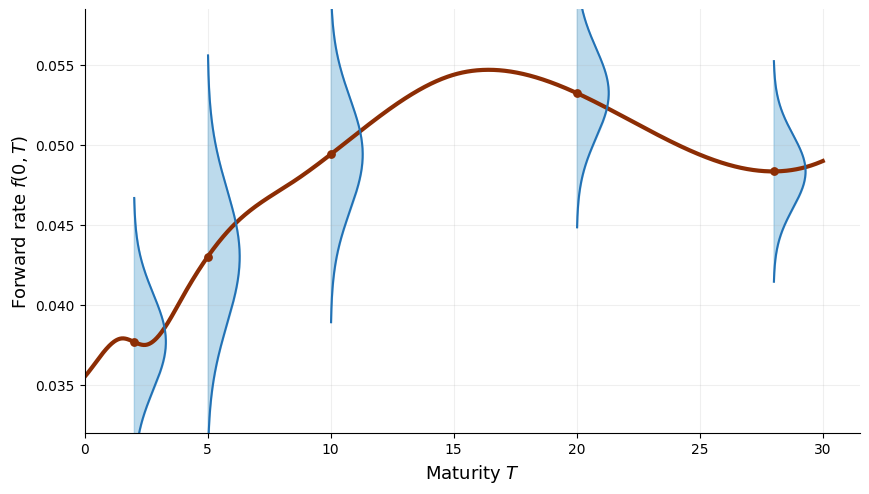

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

fwd_knots = np.array([0.0, 0.5, 1.5, 2.5, 4.0, 6.0, 8.5, 15.0, 25.0, 30.0])
fwd_vals  = np.array([0.0355, 0.0365, 0.0379, 0.0375, 0.04055, 0.0449, 0.04773, 0.0544, 0.0494, 0.0490])
cs = CubicSpline(fwd_knots, fwd_vals, bc_type='not-a-knot')
maturity = np.linspace(0, 30, 1201)
forward_curve = cs(maturity)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(maturity, forward_curve, color='#8c2d04', linewidth=3)

pillars = np.array([2, 5, 10, 20, 28], dtype=float)
pillar_forwards = cs(pillars)
vols = np.array([0.0030, 0.0042, 0.0035, 0.0028, 0.0023])
width_scale = 1.3

for pillar, center, vol in zip(pillars, pillar_forwards, vols):
    move = np.linspace(-3 * vol, 3 * vol, 250)
    density = np.exp(-0.5 * (move / vol) ** 2)
    density /= density.max()
    x_right = pillar + width_scale * density
    ax.fill_betweenx(center + move, pillar, x_right, color='#6baed6', alpha=0.45)
    ax.plot(x_right, center + move, color='#2171b5', linewidth=1.5)
    ax.scatter([pillar], [center], color='#8c2d04', s=28, zorder=3)

ax.set_xlim(0, 31.5)
ax.set_ylim(0.032, 0.0585)
ax.set_xlabel('Maturity $T$', fontsize=13)
ax.set_ylabel('Forward rate $f(0,T)$', fontsize=13)
ax.grid(alpha=0.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()


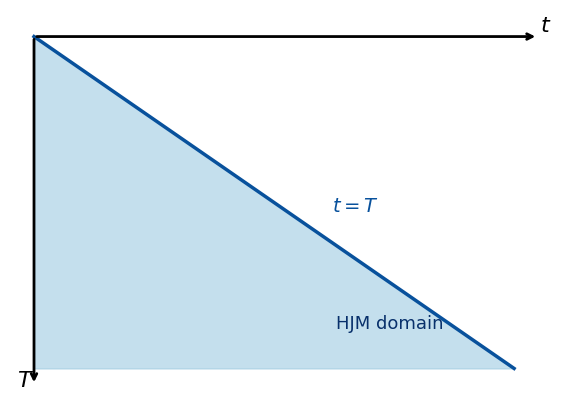

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Use y = -T so the T-axis points downward on the page.
t_max = 10
T_max = 10

t = np.linspace(0, t_max, 400)
y_line = -t

# Shade the region below the line t = T in the fourth quadrant.
ax.fill_between(t, y_line, -T_max, color="#9ecae1", alpha=0.6)
ax.plot(t, y_line, color="#08519c", linewidth=2.5)

# Clean frame and draw custom axes.
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(-0.5, t_max + 0.8)
ax.set_ylim(-T_max - 0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])

ax.annotate("", xy=(t_max + 0.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))
ax.annotate("", xy=(0, -T_max - 0.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))

ax.text(t_max + 0.55, 0.15, r"$t$", fontsize=16)
ax.text(-0.35, -T_max - 0.55, r"$T$", fontsize=16)
ax.text(6.2, -5.3, r"$t = T$", color="#08519c", fontsize=14)
ax.text(6.3, -8.8, "HJM domain", color="#08306b", fontsize=13)

plt.show()

In [2]:
# %matplotlib inline
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

@interact(m=(-2.0, 2.0), b=(-3, 3, 0.5))
def f(m=0, b=0):
    plt.figure(2)
    x = np.linspace(-10, 10, num=1000)
    plt.plot(x, m * x + b)
    plt.ylim(-5, 5)
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='m', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…